## number of jets , genvistau > 130 & eta <  2.1  , reco tau > 130 , eta < 2.1 with num > 0


In [ ]:
from importlib import import_module
import os
import sys
import argparse
import linecache
import uproot
import vector
import math
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
from tqdm import tqdm  # ✅ 진행률 표시
import glob
import json
vector.register_awkward()
import cmsstyle as CMS
import mplhep as hep
import matplotlib.pyplot as plt
sample = "/gv0/Users/achihwan/phase2/cmssw_16/condor/hltrun/new_150.root"
file = uproot.open(sample)
events = file["Events"]
runs = file["Runs"]
keys = events.keys()

def deltaR(eta1,phi1,eta2,phi2):
    delta_eta = eta1 - eta2
    delta_phi = phi1 - phi2
    delta_phi = (delta_phi + math.pi) % (2 * math.pi) - math.pi
    return np.sqrt(delta_eta**2 + delta_phi**2)


In [25]:
genvis_tau_pt = events["GenVisTau_pt"].array()
genvis_tau_eta = events["GenVisTau_eta"].array()
genvis_tau_phi = events["GenVisTau_phi"].array()
genvis_tau_mass = events["GenVisTau_mass"].array()
    
genjet_pt = events["GenJet_pt"].array()
genjet_eta = events["GenJet_eta"].array()
genjet_phi = events["GenJet_phi"].array()

tau_pt = events["hltHpsPFTau_pt"].array()
tau_eta = events["hltHpsPFTau_eta"].array()
tau_phi = events["hltHpsPFTau_phi"].array()
tau_mass = events["hltHpsPFTau_mass"].array()

ak4jet_pt = events["hltAK4PuppiJet_pt"].array()
ak4jet_eta = events["hltAK4PuppiJet_eta"].array()
ak4jet_phi = events["hltAK4PuppiJet_phi"].array()



gen_obj_mask = (genvis_tau_pt > 130) & (abs(genvis_tau_eta) < 2.1)
reco_obj_mask = (tau_pt > 130) & (abs(tau_eta) < 2.1)

gen_event_mask = ak.any(gen_obj_mask, axis=1)
reco_event_mask = ak.any(reco_obj_mask,axis=1)

both_mask = gen_event_mask & reco_event_mask
print(both_mask)

genvis_tau_pt   = genvis_tau_pt[both_mask]
genvis_tau_eta  = genvis_tau_eta[both_mask]
genvis_tau_phi  = genvis_tau_phi[both_mask]

genjet_pt   = genjet_pt[both_mask]
genjet_eta = genjet_eta[both_mask]
genjet_phi = genjet_phi[both_mask]

tau_pt = tau_pt[both_mask]
tau_eta = tau_eta[both_mask]
tau_phi = tau_phi[both_mask]

ak4jet_pt = ak4jet_pt[both_mask]
ak4jet_eta = ak4jet_eta[both_mask]
ak4jet_phi = ak4jet_phi[both_mask]




print(genvis_tau_pt)
print(genjet_pt)
numofjet = []
jet_pts = []

for i in range(len(genvis_tau_pt)):
    n_genjet = len(genjet_pt[i])
    
    is_non_tau_jet = np.ones(n_genjet, dtype=bool)
    
    for j in range(len(genvis_tau_pt[i])):
        dr = deltaR(genvis_tau_eta[i][j], genvis_tau_phi[i][j],
                    genjet_eta[i], genjet_phi[i])
        is_non_tau_jet = is_non_tau_jet & (dr > 0.3)
    
    numofjet.append(np.sum(is_non_tau_jet))
    
    # non-tau jet의 pt만 저장
    non_tau_jet_pt = np.array(genjet_pt[i])[is_non_tau_jet]
    jet_pts.append(non_tau_jet_pt)

[True, False, False, False, False, False, ..., False, True, False, False, False]
[[203, 150], [222, 188], [290, 182], ..., [165, 48.4], [242], [234, 40.6]]
[[213, 150, 21.1, 14], ..., [235, 49.7, 48.7, 14.8, ..., 11, 10.9, 10.7, 10.6]]


In [35]:
values, counts = np.unique(numofjet, return_counts=True)
for v, c in zip(values, counts):
    print(f"{v}개 jet: {c} 이벤트")
    
for n in range(max(numofjet) + 1):
    pts = [jet_pts[i][k] for i, num in enumerate(numofjet) 
           if num > n for k in [n]]  # n번째 jet pt (pT 순 정렬 안 된 경우 주의)




0개 jet: 809 이벤트
1개 jet: 1458 이벤트
2개 jet: 1390 이벤트
3개 jet: 982 이벤트
4개 jet: 599 이벤트
5개 jet: 354 이벤트
6개 jet: 207 이벤트
7개 jet: 98 이벤트
8개 jet: 44 이벤트
9개 jet: 33 이벤트
10개 jet: 6 이벤트
11개 jet: 4 이벤트
12개 jet: 4 이벤트
15개 jet: 1 이벤트
[85.58683  11.675208]


In [37]:
from collections import defaultdict

# jet 개수별로 pt 그룹화
jet_pt_by_count = defaultdict(list)

for i, num in enumerate(numofjet):
    jet_pt_by_count[num].extend(jet_pts[i])

# 확인
values, counts = np.unique(numofjet, return_counts=True)
for v, c in zip(values, counts):
    print(f"{v}개 jet: {c} 이벤트, pt list 길이: {len(jet_pt_by_count[v])}")


0개 jet: 809 이벤트, pt list 길이: 0
1개 jet: 1458 이벤트, pt list 길이: 1458
2개 jet: 1390 이벤트, pt list 길이: 2780
3개 jet: 982 이벤트, pt list 길이: 2946
4개 jet: 599 이벤트, pt list 길이: 2396
5개 jet: 354 이벤트, pt list 길이: 1770
6개 jet: 207 이벤트, pt list 길이: 1242
7개 jet: 98 이벤트, pt list 길이: 686
8개 jet: 44 이벤트, pt list 길이: 352
9개 jet: 33 이벤트, pt list 길이: 297
10개 jet: 6 이벤트, pt list 길이: 60
11개 jet: 4 이벤트, pt list 길이: 44
12개 jet: 4 이벤트, pt list 길이: 48
15개 jet: 1 이벤트, pt list 길이: 15


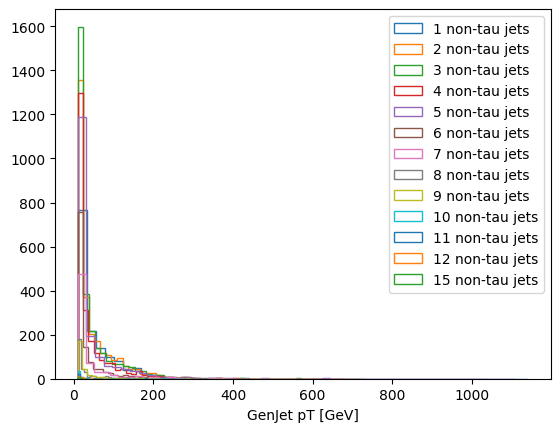

In [38]:
for v in sorted(jet_pt_by_count.keys()):
    if v == 0:
        continue
    plt.hist(jet_pt_by_count[v], bins=50, label=f"{v} non-tau jets", histtype="step")

plt.xlabel("GenJet pT [GeV]")
plt.legend()
plt.show()

[np.float32(17.418905), np.float32(28.137138), np.float32(93.66108), np.float32(159.34392), np.float32(32.44348), np.float32(92.47485), np.float32(85.982574), np.float32(84.46575), np.float32(15.011659), np.float32(12.383174), np.float32(13.872147), np.float32(51.167336), np.float32(17.937847), np.float32(32.67499), np.float32(41.4426), np.float32(23.880144), np.float32(161.18819), np.float32(25.154165), np.float32(33.17655), np.float32(140.31425), np.float32(10.216295), np.float32(42.473347), np.float32(47.834827), np.float32(45.96935), np.float32(25.332695), np.float32(12.42797), np.float32(29.941181), np.float32(12.565737), np.float32(72.43618), np.float32(13.0727625), np.float32(45.138657), np.float32(15.228964), np.float32(14.269565), np.float32(12.368914), np.float32(42.38927), np.float32(127.63554), np.float32(24.189539), np.float32(17.221436), np.float32(10.640245), np.float32(36.03812), np.float32(46.71311), np.float32(24.069435), np.float32(33.235348), np.float32(65.95137), n